<a href="https://colab.research.google.com/github/Ahiraf/Data_Science_Basics/blob/main/Mean_Median_Mode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mean**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
ar = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
s = np.sum(ar)
l = len(ar)
mean = s/l
print(mean)

5.5


# Using "mean" function

In [8]:
mean = np.mean(ar)
print(mean)

5.5


# Finding Mean from a CSV file

In [9]:
dataset = pd.read_csv("/content/Titanic-Dataset.csv")
dataset.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [10]:
dataset["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [11]:
dataset["Age"].mean()

np.float64(29.69911764705882)

In [12]:
np.mean(dataset["Age"]) # or I can find the mean using Numpy's mean function

np.float64(29.69911764705882)

# Graphs for showing the mean value graphically

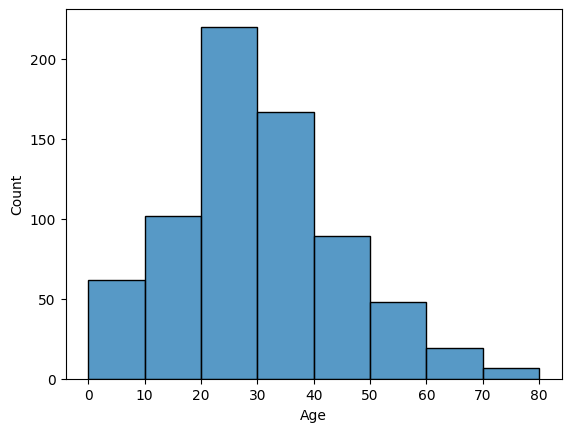

In [13]:
sns.histplot(x = "Age", data = dataset, bins = [i for i in range(0, 81, 10)]) #histplot(x axis's value and name same as dataset's column, y axis's name and value)
plt.show()

# mean vs count graph

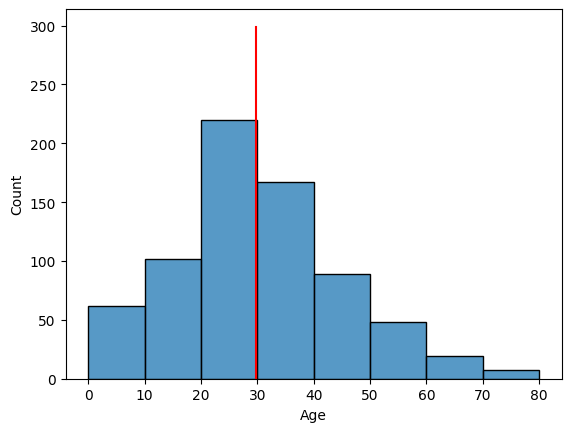

In [14]:
mn = np.mean(dataset["Age"])
plt.plot([mn for i in range(0, 300)], [i for i in range (0, 300)], c = "red") # Here 'c' means color
sns.histplot(x = "Age", data = dataset, bins = [i for i in range(0, 81, 10)])
plt.show()

In [15]:
# My previous misunderstanding:
# I thought repeating x 300 times and having 300 y values would create 300 separate lines.

# Correct understanding:
# plt.plot(x, y) does NOT create multiple lines.
# It creates points by pairing elements:
# (x[0], y[0]), (x[1], y[1]), (x[2], y[2]), ...

# In this case:
# x = [mn, mn, mn, ...]  # same value repeated 300 times
# y = [0, 1, 2, ..., 299]

# So the points become:
# (mn, 0), (mn, 1), (mn, 2), ...

# Since x is constant and y changes,
# all points lie vertically above each other.
# matplotlib connects these points into ONE continuous line.

# Therefore:
# Constant x + changing y  → Vertical line
# Changing x + constant y  → Horizontal line

# Important rule:
# x and y must have the same LENGTH like here "in range [0, 300] is used", both have 300 length or 300 points because point = [x, y] so number of x = number of y
# but their actual values do NOT have to be the same.

# **Median: Mid value of a dataset**

In [16]:
med = np.median(dataset["Age"])
print(med)

nan


In [17]:
#As there are so many NAN values in Age column we have to use the 'Data Cleaning' process first.
dataset.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
# So there are 177 nan values in Age column. So, first this nan values should be filled by data cleaning.
# Measurement of central tendency (mean, median, mode) is widely used in data cleaning
dataset["Age"].fillna(dataset["Age"].mean(), inplace = True) # here the nan values are filling with the mean values.

In [19]:
med = np.median(dataset["Age"])
print(med)

29.69911764705882


In [20]:
dataset["Age"].median()

29.69911764705882

# Mean and Median for Fare column

In [21]:
mnFare = np.mean(dataset["Fare"])
print(mnFare)

32.204207968574636


In [22]:
mdFare = np.median(dataset["Fare"]) # no need for data cleaning as there is no NAN values in Fare column
print(mdFare)

14.4542


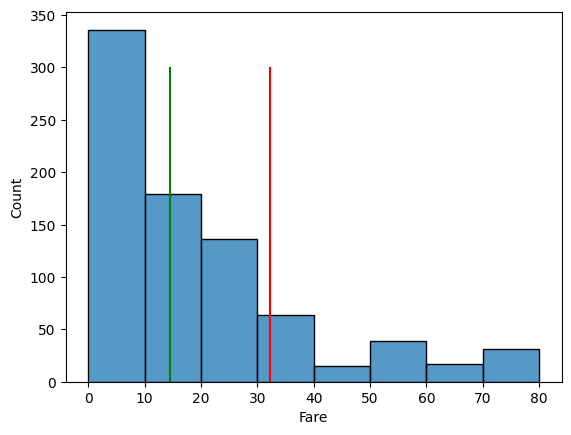

In [23]:
plt.plot([mnFare for i in range(0, 300)], [i for i in range(0, 300)], c = "red")
plt.plot([mdFare for i in range(0, 300)], [i for i in range(0, 300)], c = "green")
sns.histplot(x = "Fare", data = dataset, bins = [i for i in range(0, 81, 10)])
plt.show()

# **Mode : The data which has the most frequency **
**It is used on categorical data like: 'gender', 'class', 'who' columns in titanic dataset**

In [33]:
mo = dataset["Sex"].mode()
print(type(dataset["Sex"].mode()))  # As it is Series type only one element from this Series should be print
print(mo[0])

<class 'pandas.core.series.Series'>
male


In [34]:
mo1 = dataset["Fare"].mode()[0]
print(mo1)

8.05


# For checking Frequency

In [35]:
dataset["Fare"].value_counts() # Most frequency is 43 of 8.0500

,count
Fare,
8.0500,43
13.0000,42
7.8958,38
7.7500,34
26.0000,31
...,...
13.8583,1
50.4958,1
5.0000,1


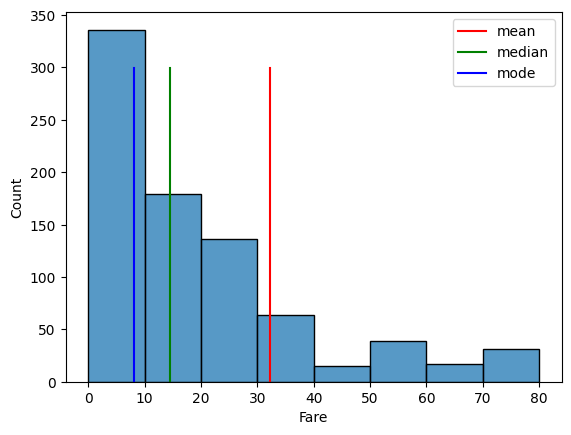

In [39]:
plt.plot([mnFare for i in range(0, 300)], [i for i in range(0, 300)], c = "red", label = "mean")
plt.plot([mdFare for i in range(0, 300)], [i for i in range(0, 300)], c = "green", label = "median")
plt.plot([mo1 for i in range(0, 300)], [i for i in range(0, 300)], c = "blue", label = "mode")
sns.histplot(x = "Fare", data = dataset, bins = [i for i in range(0, 81, 10)])
plt.legend()
plt.show()

# If the dataset is Symmetrical then mean, median, mode are same.